# 📊 Telecom Customer Churn Dataset

**Task:** Binary classification: Predict customer churn 
**Dataset:** Telco Customer Churn Dataset ([Kaggle](https://www.kaggle.com/datasets/abbas829/telco-customer-churn-dataset))  
**Model:** Logistic Regression(the best recall),Decisin tree,Rondom Forest,SVM,XGBOOST

---

##  Section 1 — Import Libraries

In [65]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 
import warnings 
warnings.filterwarnings('ignore')

##  Section 2 — Load Dataset

In [66]:
df=pd.read_csv(r"C:\Users\Habiba Elboraii\Downloads\archive (4)\telco_data.csv")

##  Section 3 — EDA

In [67]:
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [68]:
df.shape

(7043, 21)

In [69]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            6293 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           6043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            4543 non-null   float64
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   6043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       5543 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [70]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,4543.000000,5543.000000
mean,0.162147,32.546555,64.876403
std,0.368612,24.505519,30.101331
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.750000
50%,0.000000,29.000000,70.550000
75%,0.000000,56.000000,89.925000
max,1.000000,72.000000,118.600000


In [71]:
df.isnull().sum()

customerID             0
gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

In [72]:
df.duplicated().sum()

0

In [73]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

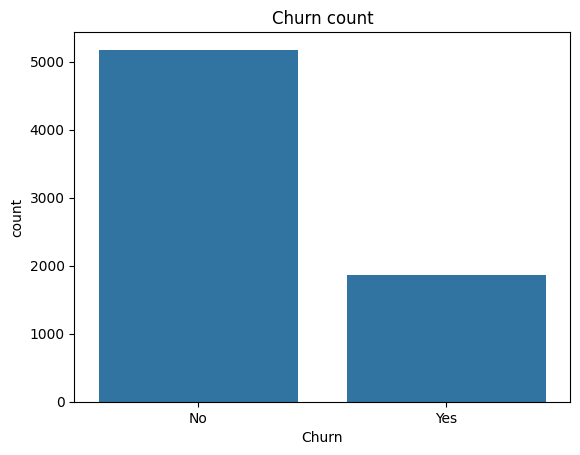

In [74]:
#Churn
sns.countplot(x='Churn',data=df)
plt.title('Churn count')
plt.show()

In [75]:
df['gender'].value_counts()

gender
Male      3202
Female    3091
Name: count, dtype: int64

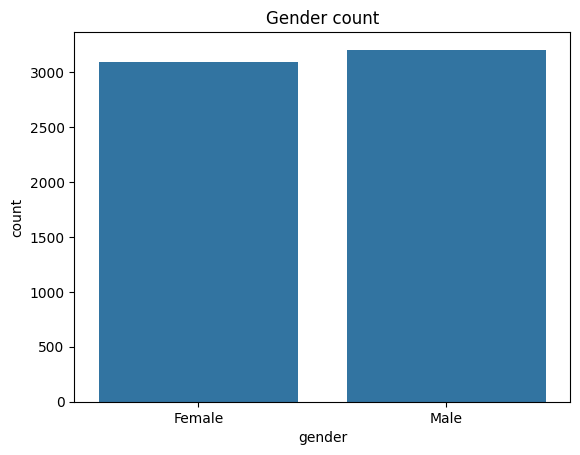

In [76]:
#gender
sns.countplot(x='gender',data=df)
plt.title('Gender count')
plt.show()

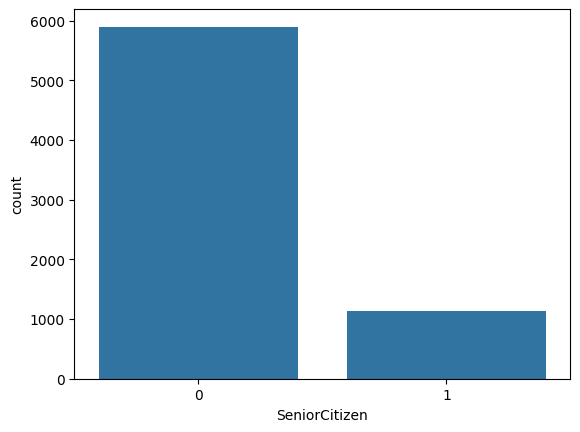

In [77]:
#SeniorCitizen
sns.countplot(x='SeniorCitizen',data=df)
plt.show()

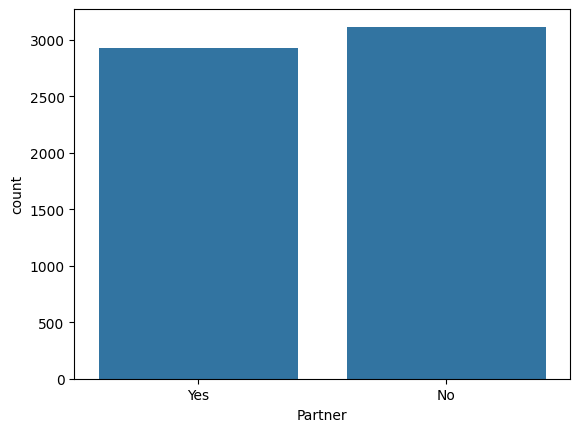

In [78]:
#Partner 
sns.countplot(x='Partner',data=df)
plt.show()

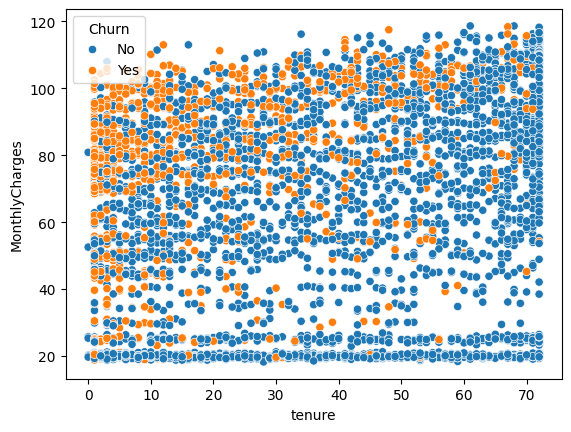

In [79]:
sns.scatterplot(x='tenure', y='MonthlyCharges', hue='Churn', data=df)
plt.show()

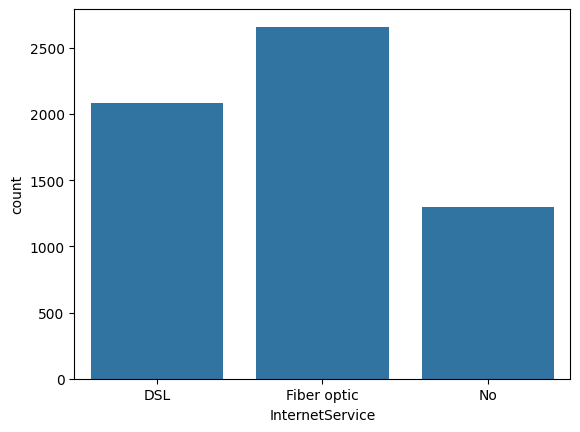

In [80]:
#InternetService
sns.countplot(x='InternetService',data=df)
plt.show()

In [81]:
df['PaymentMethod'].value_counts()

PaymentMethod
Electronic check             2365
Mailed check                 1612
Bank transfer (automatic)    1544
Credit card (automatic)      1522
Name: count, dtype: int64

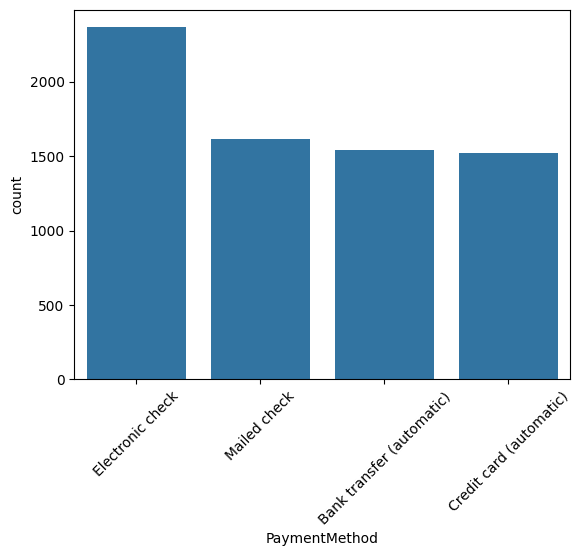

In [82]:
#PaymentMethod
sns.countplot(x='PaymentMethod',data=df)
plt.xticks(rotation=45)
plt.show()

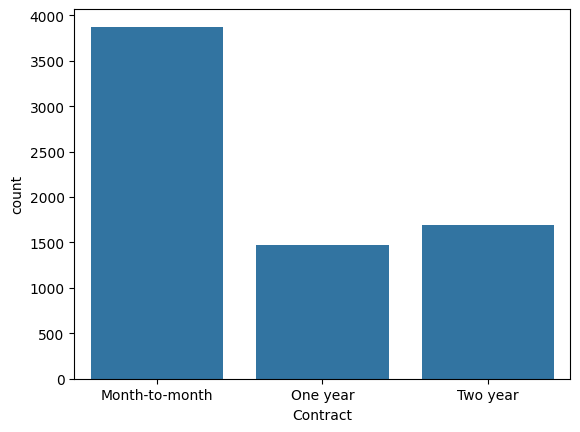

In [83]:
#Contract
sns.countplot(x='Contract',data=df)
plt.show()

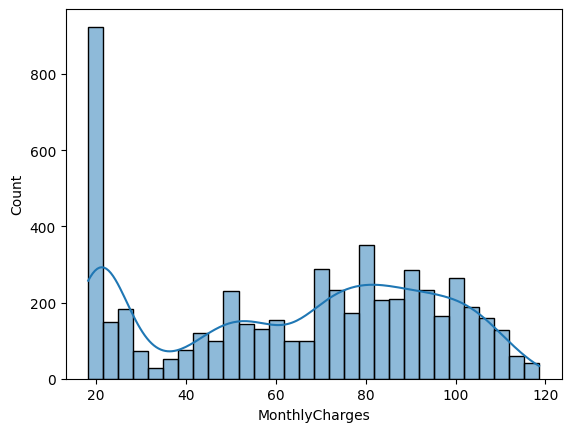

In [84]:
#MonthlyCharges	
sns.histplot(x='MonthlyCharges',data=df,bins=30,kde=True)
plt.show()

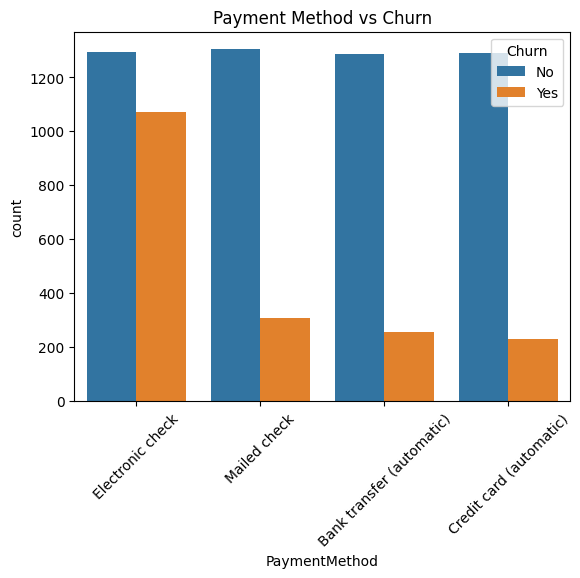

In [85]:
sns.countplot(x='PaymentMethod', hue='Churn', data=df)
plt.title('Payment Method vs Churn')
plt.xticks(rotation=45)
plt.show()

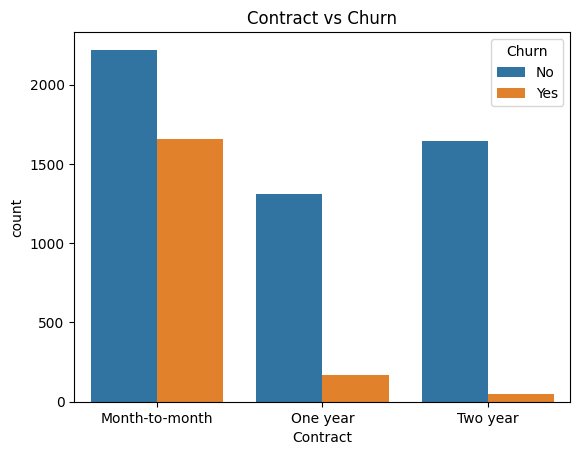

In [86]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.title('Contract vs Churn')
plt.show()

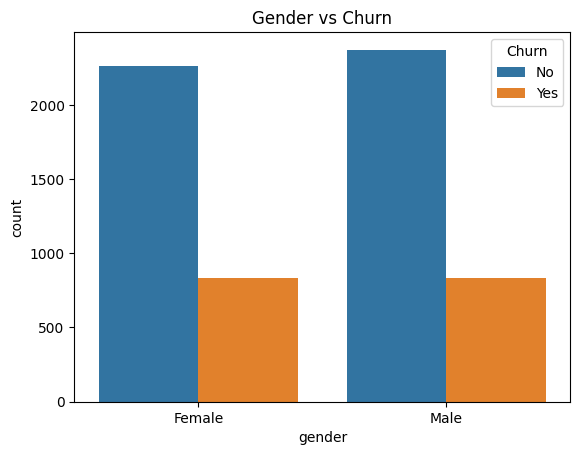

In [87]:
sns.countplot(x='gender', hue='Churn', data=df)
plt.title('Gender vs Churn')
plt.show()

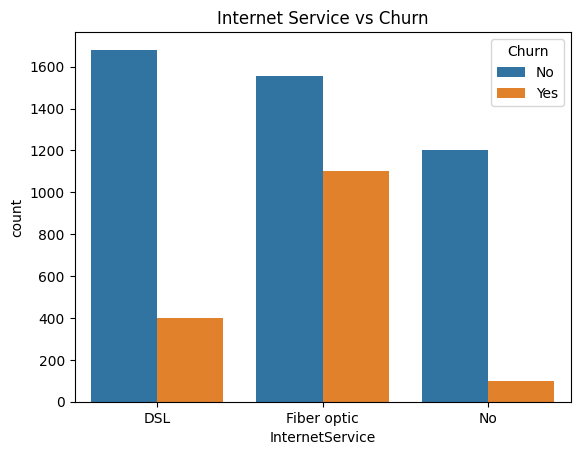

In [88]:
sns.countplot(x='InternetService', hue='Churn', data=df)
plt.title('Internet Service vs Churn')
plt.show()

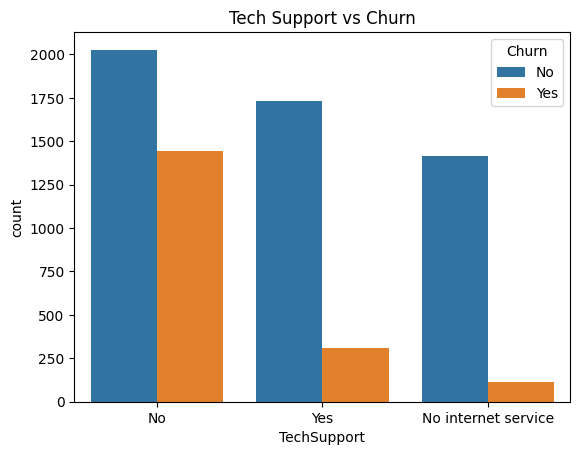

In [89]:
sns.countplot(x='TechSupport', hue='Churn', data=df)
plt.title('Tech Support vs Churn')
plt.show()

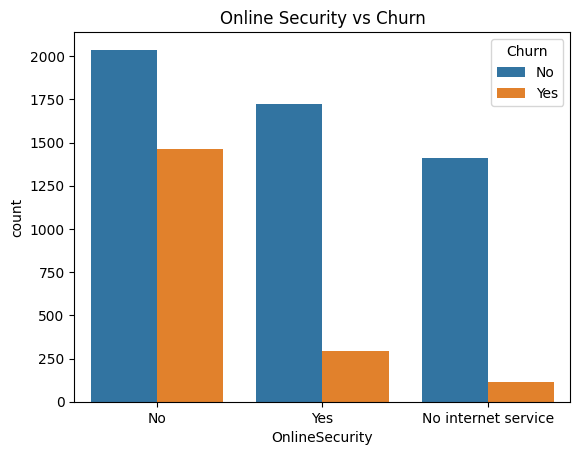

In [90]:
sns.countplot(x='OnlineSecurity', hue='Churn', data=df)
plt.title('Online Security vs Churn')
plt.show()

In [91]:
df['Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [92]:
df['Churn'].value_counts()

Churn
0    5174
1    1869
Name: count, dtype: int64

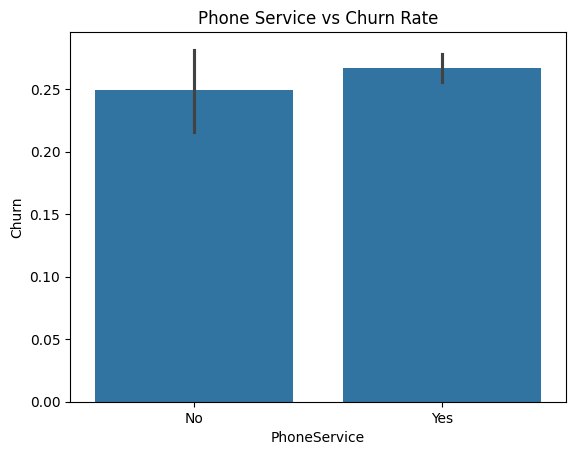

In [93]:
sns.barplot(x='PhoneService', y='Churn', data=df)
plt.title('Phone Service vs Churn Rate')
plt.show()

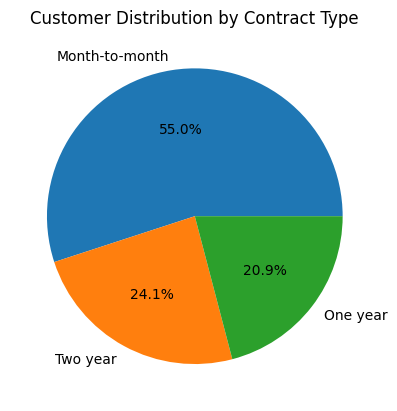

In [94]:
df['Contract'].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Customer Distribution by Contract Type')
plt.ylabel('')
plt.show()

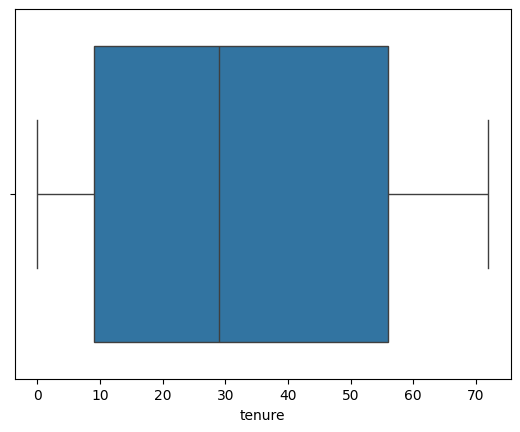

In [95]:
sns.boxplot(x='tenure', data=df)
plt.show()

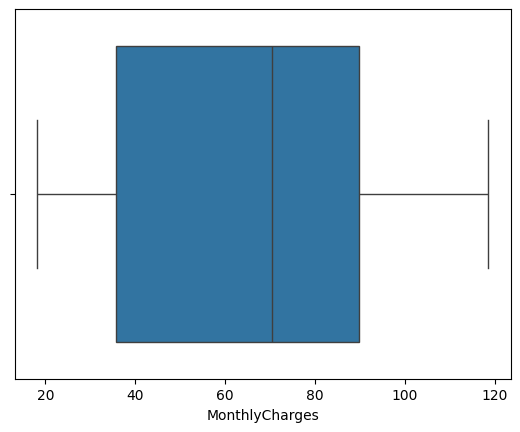

In [96]:
sns.boxplot(x='MonthlyCharges', data=df)
plt.show()

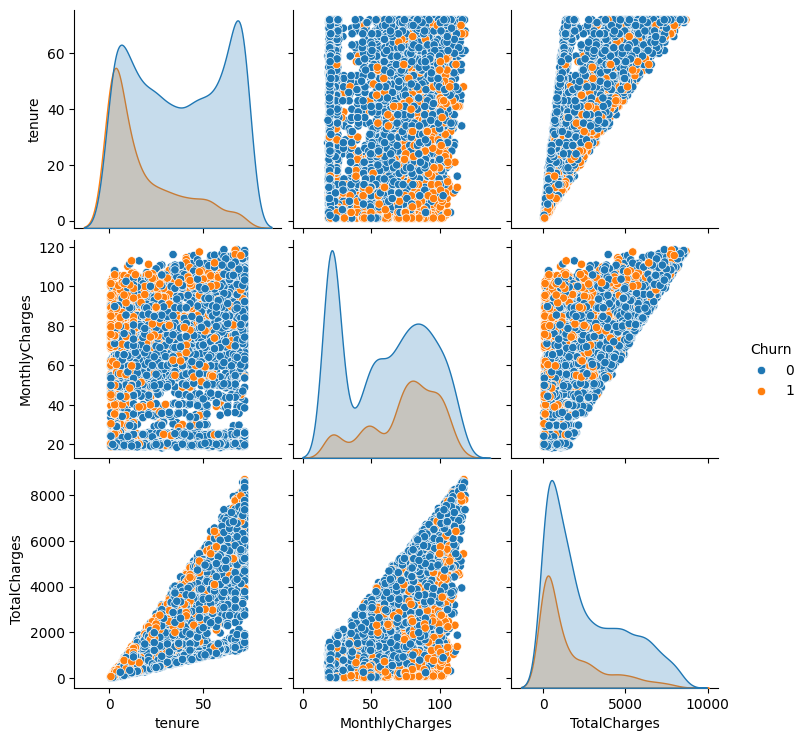

In [97]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

numeric_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
plot_df = df[numeric_cols + ['Churn']].dropna()

sns.pairplot(plot_df, hue='Churn', vars=numeric_cols)
plt.show()

## Section 4 -Data preprocessing 

In [98]:
#1- feature selection
#2- Null Values
#3- Encoding
#4- Splitting
#5- Scaling
#6- handle imbalanced data

### 1- Feature selection

In [99]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1.0,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34.0,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2.0,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45.0,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2.0,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


In [100]:
df.drop(columns = ['customerID'],inplace = True)

In [101]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1.0,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34.0,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2.0,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,Male,0,No,No,45.0,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,Female,0,No,No,2.0,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1


### 2- Handle missing value

In [102]:
df.isnull().sum()

gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges          11
Churn                  0
dtype: int64

In [103]:
#1-TotalCharges 
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

In [104]:
df.isnull().sum()

gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges      1500
TotalCharges           0
Churn                  0
dtype: int64

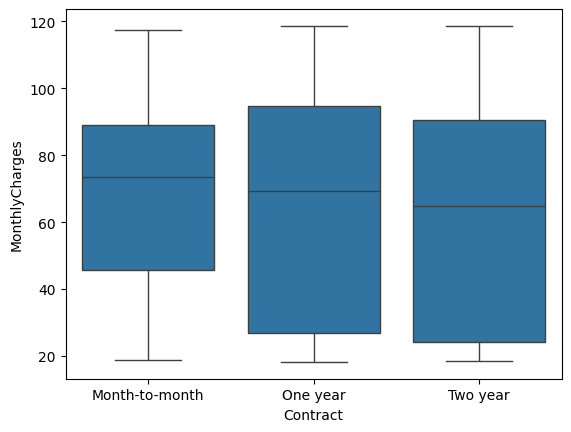

In [105]:
#2-MonthlyCharges
sns.boxplot(x= 'Contract',y = 'MonthlyCharges',data = df)
plt.show()

In [106]:
def imput_nulls_MonthlyCharges(cols):
    '''
    first col --> MonthlyCharges,
    Se --> Contract
    ''' 
    MonthlyCharges = cols[0]
    Contract = cols[1]
    if pd.isnull(MonthlyCharges):
        if Contract == 'Month-to-month':
            return 75
        elif Contract == 'One year':
            return 70
        else:
            return 65
    else:
        return MonthlyCharges

In [107]:
df['MonthlyCharges'] = df[['MonthlyCharges','Contract']].apply(imput_nulls_MonthlyCharges,axis = 1)

In [108]:
df.isnull().sum()

gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService     1000
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

In [109]:
df['InternetService'].value_counts()

InternetService
Fiber optic    2660
DSL            2082
No             1301
Name: count, dtype: int64

In [110]:
#3-InternetService
df['InternetService'] = df['InternetService'].fillna(
    df['InternetService'].mode()[0]
)

In [111]:
df['InternetService'].value_counts()

InternetService
Fiber optic    3660
DSL            2082
No             1301
Name: count, dtype: int64

In [112]:
df.isnull().sum()

gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure              2500
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

In [113]:
#4-tenure
df['tenure'] = df['tenure'].fillna(df['tenure'].median())

In [114]:
df.isnull().sum()

gender               750
SeniorCitizen          0
Partner             1000
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

In [115]:
df['gender'].value_counts()

gender
Male      3202
Female    3091
Name: count, dtype: int64

In [116]:
#5-gender
df['gender'] = df['gender'].fillna(df['gender'].mode()[0])

In [117]:
df['gender'].value_counts()

gender
Male      3952
Female    3091
Name: count, dtype: int64

In [118]:
df.isnull().sum()

gender                 0
SeniorCitizen          0
Partner             1000
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

In [119]:
df['Partner'].value_counts()

Partner
No     3115
Yes    2928
Name: count, dtype: int64

In [120]:
#6-Partner
df['Partner'] = df['Partner'].fillna(df['Partner'].mode()[0])

In [121]:
df['Partner'].value_counts()

Partner
No     4115
Yes    2928
Name: count, dtype: int64

In [122]:
df.isnull().sum()

gender                 0
SeniorCitizen          0
Partner                0
Dependents             0
tenure                 0
PhoneService           0
MultipleLines          0
InternetService        0
OnlineSecurity         0
OnlineBackup           0
DeviceProtection       0
TechSupport            0
StreamingTV         1500
StreamingMovies        0
Contract               0
PaperlessBilling       0
PaymentMethod          0
MonthlyCharges         0
TotalCharges           0
Churn                  0
dtype: int64

In [123]:
#7- streamingTV
df['StreamingTV'] = df['StreamingTV'].fillna(df['StreamingTV'].mode()[0])

In [124]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### 3- Encoding categorical variables

In [125]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


In [126]:
def encode_categorical_features(df):
    
    categorical_cols = df.select_dtypes(include='object').columns
    
    encoders = {}

    for col in categorical_cols:
        le = LabelEncoder()
        df[col] = le.fit_transform(df[col])
        encoders[col] = le

    return df, encoders

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded, encoders = encode_categorical_features(df)
df = df_encoded

NameError: name 'LabelEncoder' is not defined

In [128]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            7043 non-null   object 
 1   SeniorCitizen     7043 non-null   int64  
 2   Partner           7043 non-null   object 
 3   Dependents        7043 non-null   object 
 4   tenure            7043 non-null   float64
 5   PhoneService      7043 non-null   object 
 6   MultipleLines     7043 non-null   object 
 7   InternetService   7043 non-null   object 
 8   OnlineSecurity    7043 non-null   object 
 9   OnlineBackup      7043 non-null   object 
 10  DeviceProtection  7043 non-null   object 
 11  TechSupport       7043 non-null   object 
 12  StreamingTV       7043 non-null   object 
 13  StreamingMovies   7043 non-null   object 
 14  Contract          7043 non-null   object 
 15  PaperlessBilling  7043 non-null   object 
 16  PaymentMethod     7043 non-null   object 


### 4- Spliting

In [ ]:
x = df.drop(columns = ['Churn'])
y = df.Churn

In [ ]:
x.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges
0,0,0,1,0,1.0,0,1,0,0,2,0,0,0,0,0,1,2,29.85,29.85
1,1,0,0,0,34.0,1,0,0,2,0,2,0,0,0,1,0,3,56.95,1889.50
2,1,0,0,0,2.0,1,0,0,2,2,0,0,0,0,0,1,3,53.85,108.15
3,1,0,0,0,45.0,0,1,0,2,0,2,2,0,0,1,0,0,42.30,1840.75
4,0,0,0,0,2.0,1,0,1,0,0,0,0,0,0,0,1,2,70.70,151.65


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size = 0.2 , random_state = 1)

In [ ]:
print('x_train shape: ',x_train.shape)
print('y_train shape: ',y_train.shape)
print('--'*20)
print('x_test shape: ',x_test.shape)
print('y_test shape: ',y_test.shape)

x_train shape:  (5634, 19)
y_train shape:  (5634,)
----------------------------------------
x_test shape:  (1409, 19)
y_test shape:  (1409,)


### 5- Scaling

In [ ]:
from sklearn.preprocessing import StandardScaler

In [ ]:
scaler = StandardScaler()

In [ ]:
X_train_scaled = scaler.fit_transform(x_train)
X_test_scaled = scaler.transform(x_test)

### 6- SMOTE

In [ ]:
from imblearn.over_sampling import SMOTE

In [ ]:
smote = SMOTE(random_state=42)

In [ ]:
X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

In [ ]:
print(y_train_smote.value_counts())

Churn
0    4113
1    4113
Name: count, dtype: int64


## Section 5- Model Traning 

### 1- Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
LR = LogisticRegression(random_state=42)

In [ ]:
LR.fit(X_train_smote, y_train_smote)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [ ]:
y_pred_LR = LR.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_LR))
print(classification_report(y_test, y_pred_LR))

[[750 311]
 [ 57 291]]
              precision    recall  f1-score   support

           0       0.93      0.71      0.80      1061
           1       0.48      0.84      0.61       348

    accuracy                           0.74      1409
   macro avg       0.71      0.77      0.71      1409
weighted avg       0.82      0.74      0.76      1409



### 2-Decision tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_model = DecisionTreeClassifier(random_state=42)

In [ ]:
dt_model.fit(X_train_smote, y_train_smote)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [ ]:
y_pred_dt = dt_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_dt))
print(classification_report(y_test, y_pred_dt))

[[841 220]
 [144 204]]
              precision    recall  f1-score   support

           0       0.85      0.79      0.82      1061
           1       0.48      0.59      0.53       348

    accuracy                           0.74      1409
   macro avg       0.67      0.69      0.68      1409
weighted avg       0.76      0.74      0.75      1409



### 3-Random Forest 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

In [ ]:
rf_model.fit(X_train_smote, y_train_smote)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [ ]:
y_pred_rf = rf_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_rf))
print(classification_report(y_test, y_pred_rf))

[[886 175]
 [130 218]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.85      1061
           1       0.55      0.63      0.59       348

    accuracy                           0.78      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.79      0.78      0.79      1409



### 4- SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_model = SVC(random_state=42)

In [ ]:
svm_model.fit(X_train_smote, y_train_smote)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [ ]:
y_pred_svm = svm_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_svm))
print(classification_report(y_test, y_pred_svm))

[[801 260]
 [ 91 257]]
              precision    recall  f1-score   support

           0       0.90      0.75      0.82      1061
           1       0.50      0.74      0.59       348

    accuracy                           0.75      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



### 5- XGBOOST

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_model = XGBClassifier(
    n_estimators=100,
    random_state=42,
    eval_metric='logloss'
)

In [ ]:
xgb_model.fit(X_train_smote, y_train_smote)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [ ]:
y_pred_xgb = xgb_model.predict(X_test_scaled)

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix

print(confusion_matrix(y_test, y_pred_xgb))
print(classification_report(y_test, y_pred_xgb))

[[894 167]
 [135 213]]
              precision    recall  f1-score   support

           0       0.87      0.84      0.86      1061
           1       0.56      0.61      0.59       348

    accuracy                           0.79      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.79      0.79      0.79      1409



In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

models_predictions = {
    'Logistic Regression': y_pred_LR,
    'Decision Tree': y_pred_dt,
    'Random Forest': y_pred_rf,
    'SVM': y_pred_svm,
    'XGBoost': y_pred_xgb
}

results = []

for name, y_pred in models_predictions.items():
    
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

results_df = pd.DataFrame(results)

results_df.sort_values(
    by='F1-Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.738822,0.483389,0.836207,0.612632
3,SVM,0.750887,0.497099,0.738506,0.594220
2,Random Forest,0.783534,0.554707,0.626437,0.588394
4,XGBoost,0.785664,0.560526,0.612069,0.585165
1,Decision Tree,0.741661,0.481132,0.586207,0.528497


## Section 6-Hyperparameter Tuning

### 1- Logistic regression

In [ ]:
from sklearn.model_selection import GridSearchCV

In [ ]:
from sklearn.linear_model import LogisticRegression

In [ ]:
log_params = {
    'C': [0.01, 0.1, 1, 10, 100],
    'solver': ['liblinear', 'lbfgs'],
    'max_iter': [500, 1000]
}

In [ ]:
log_grid = GridSearchCV(
    LogisticRegression(random_state=42),
    log_params,
    cv=5,
    scoring='f1',
    n_jobs=2
)

log_grid.fit(X_train_smote, y_train_smote)

,estimator,LogisticRegre...ndom_state=42)
,param_grid,"{'C': [0.01, 0.1, ...], 'max_iter': [500, 1000], 'solver': ['liblinear', 'lbfgs']}"
,scoring,'f1'
,n_jobs,2
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,penalty,'l2'


In [ ]:
print("Best Parameters:", log_grid.best_params_)

Best Parameters: {'C': 0.01, 'max_iter': 500, 'solver': 'liblinear'}


In [ ]:
print("Best F1:", log_grid.best_score_)

Best F1: 0.7726977491929545


### 2-Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier

In [ ]:
dt_params = {
    'max_depth': [3, 5, 7, 10, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}

In [ ]:
dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_params,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

dt_grid.fit(X_train_smote, y_train_smote)

,estimator,DecisionTreeC...ndom_state=42)
,param_grid,"{'criterion': ['gini', 'entropy'], 'max_depth': [3, 5, ...], 'min_samples_leaf': [1, 2, ...], 'min_samples_split': [2, 5, ...]}"
,scoring,'f1'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'gini'


In [ ]:
print("Best Parameters:", dt_grid.best_params_)

Best Parameters: {'criterion': 'gini', 'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 10}


In [ ]:
print("Best F1:", dt_grid.best_score_)

Best F1: 0.7974661548042628


### 3- Random Forest 

In [ ]:
from sklearn.ensemble import RandomForestClassifier

In [ ]:
rf_params = {
    'n_estimators': [100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2]
}

In [ ]:
rf_grid = GridSearchCV(
    RandomForestClassifier(random_state=42),
    rf_params,
    cv=5,
    scoring='f1',
    n_jobs=1
)

rf_grid.fit(X_train_smote, y_train_smote)

,estimator,RandomForestC...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], 'n_estimators': [100, 200]}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [ ]:
print("Best Parameters:", rf_grid.best_params_)

Best Parameters: {'max_depth': 20, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 200}


In [ ]:
print("Best F1:", rf_grid.best_score_)

Best F1: 0.8456242468910442


### 4-SVM

In [ ]:
from sklearn.svm import SVC

In [ ]:
svm_params = {
    'C': [0.1, 1, 10],
    'kernel': ['rbf'],
    'gamma': ['scale', 'auto']
}

In [ ]:
svm_grid = GridSearchCV(
    SVC(random_state=42),
    svm_params,
    cv=3,
    scoring='f1',
    n_jobs=1
)

svm_grid.fit(X_train_smote, y_train_smote)

,estimator,SVC(random_state=42)
,param_grid,"{'C': [0.1, 1, ...], 'gamma': ['scale', 'auto'], 'kernel': ['rbf']}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,3
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,C,10


In [ ]:
print("Best Parameters:", svm_grid.best_params_)

Best Parameters: {'C': 10, 'gamma': 'scale', 'kernel': 'rbf'}


In [ ]:
print("Best F1:", svm_grid.best_score_)

Best F1: 0.8225303640116142


### 5- XGBOOST

In [ ]:
from xgboost import XGBClassifier

In [ ]:
xgb_params = {
    'n_estimators': [100, 200, 300],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.2],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

In [ ]:
xgb_grid = GridSearchCV(
    XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    xgb_params,
    cv=5,
    scoring='f1',
    n_jobs=1
)

xgb_grid.fit(X_train_smote, y_train_smote)

,estimator,"XGBClassifier...ree=None, ...)"
,param_grid,"{'colsample_bytree': [0.8, 1.0], 'learning_rate': [0.01, 0.1, ...], 'max_depth': [3, 5, ...], 'n_estimators': [100, 200, ...], ...}"
,scoring,'f1'
,n_jobs,1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,objective,'binary:logistic'


In [ ]:
print("Best Parameters:", xgb_grid.best_params_)

Best Parameters: {'colsample_bytree': 0.8, 'learning_rate': 0.1, 'max_depth': 7, 'n_estimators': 100, 'subsample': 0.8}


In [ ]:
print("Best F1:", xgb_grid.best_score_)

Best F1: 0.8267112987471295


In [ ]:
from sklearn.metrics import classification_report

tuned_models = {
    'Logistic Regression': log_grid.best_estimator_,
    'Decision Tree': dt_grid.best_estimator_,
    'Random Forest': rf_grid.best_estimator_,
    'SVM': svm_grid.best_estimator_,
    'XGBoost': xgb_grid.best_estimator_
}

for name, model in tuned_models.items():

    y_pred = model.predict(X_test_scaled)

    print("=" * 50)
    print(name)
    print(classification_report(y_test, y_pred))

Logistic Regression
              precision    recall  f1-score   support

           0       0.93      0.69      0.79      1061
           1       0.47      0.84      0.60       348

    accuracy                           0.73      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.82      0.73      0.75      1409

Decision Tree
              precision    recall  f1-score   support

           0       0.88      0.79      0.83      1061
           1       0.51      0.67      0.58       348

    accuracy                           0.76      1409
   macro avg       0.69      0.73      0.71      1409
weighted avg       0.79      0.76      0.77      1409

Random Forest
              precision    recall  f1-score   support

           0       0.87      0.83      0.85      1061
           1       0.55      0.64      0.59       348

    accuracy                           0.78      1409
   macro avg       0.71      0.73      0.72      1409
weighted avg       0.79   

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import pandas as pd

results = []

for name, model in tuned_models.items():

    y_pred = model.predict(X_test_scaled)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred)
    })

tuned_results = pd.DataFrame(results)

tuned_results.sort_values(
    by='F1-Score',
    ascending=False
)

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.727466,0.470874,0.836207,0.602484
4,XGBoost,0.781405,0.548077,0.655172,0.596859
2,Random Forest,0.781405,0.549751,0.635057,0.589333
1,Decision Tree,0.758694,0.508696,0.672414,0.579208
3,SVM,0.743790,0.486486,0.672414,0.564536


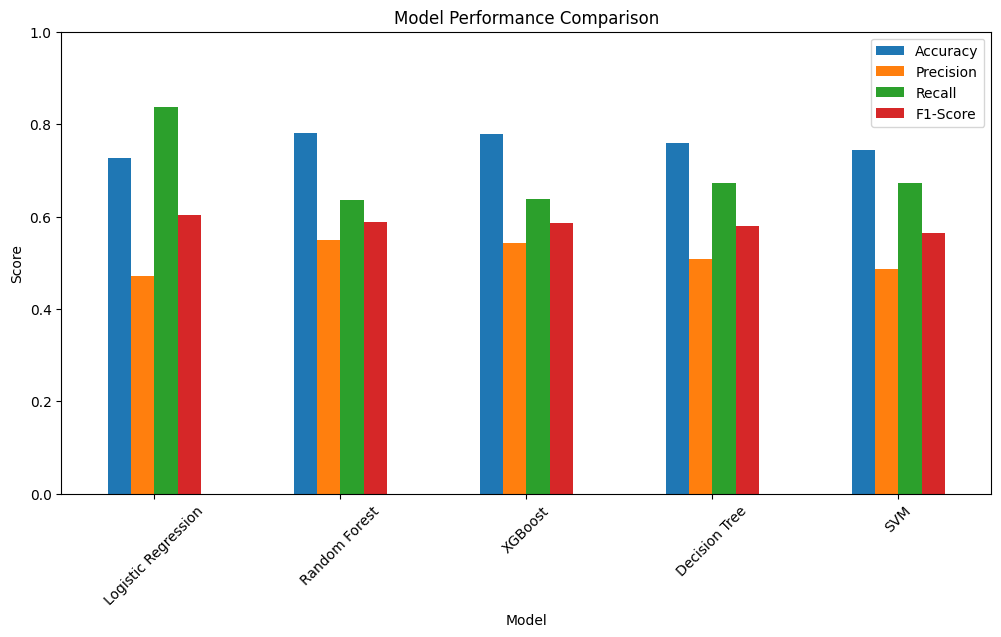

In [ ]:
results_df = pd.DataFrame({
    'Model': ['Logistic Regression', 'Random Forest', 'XGBoost',
              'Decision Tree', 'SVM'],
    'Accuracy': [0.727466, 0.781405, 0.777857, 0.758694, 0.743790],
    'Precision': [0.470874, 0.549751, 0.542787, 0.508696, 0.486486],
    'Recall': [0.836207, 0.635057, 0.637931, 0.672414, 0.672414],
    'F1-Score': [0.602484, 0.589333, 0.586526, 0.579208, 0.564536]
})

results_df.set_index('Model').plot(kind='bar', figsize=(12,6))

plt.title('Model Performance Comparison')
plt.ylabel('Score')
plt.xlabel('Model')
plt.xticks(rotation=45)
plt.ylim(0, 1)
plt.legend()
plt.show()

## Section 7- Sava the model

In [ ]:
import joblib

best_log_model = log_grid.best_estimator_

joblib.dump(best_log_model, "log_churn_model.pkl")

['xgb_churn_model.pkl']

In [ ]:
joblib.dump(scaler, 'scaler.pkl')

['scaler.pkl']

In [ ]:
joblib.dump(encoders, "encoders.pkl")

['encoders.pkl']